In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import RidgeCV, LogisticRegression
from sklearn.feature_selection import SelectFromModel, SequentialFeatureSelector, SelectKBest, f_classif

from sklearn.metrics import roc_auc_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.svm import LinearSVC

from time import time

In [2]:
# Load Dataset
df = pd.read_csv("../dataset/breast-cancer-cleaned.csv")

print(f"rows: {df.shape[0]}, columns: {df.shape[1]}")
df.head()

rows: 569, columns: 31


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
# Separate features and target variable
X = df.drop("diagnosis", axis=1)
y = df["diagnosis"]

print(f"Features shape: {X.shape}")
print(f"Target distribution:\n{y.value_counts()}")
print(f"\nFeature columns: {X.columns.tolist()}")

Features shape: (569, 30)
Target distribution:
diagnosis
0    357
1    212
Name: count, dtype: int64

Feature columns: ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']


# Model-based and sequential feature selection

## Model-based selection

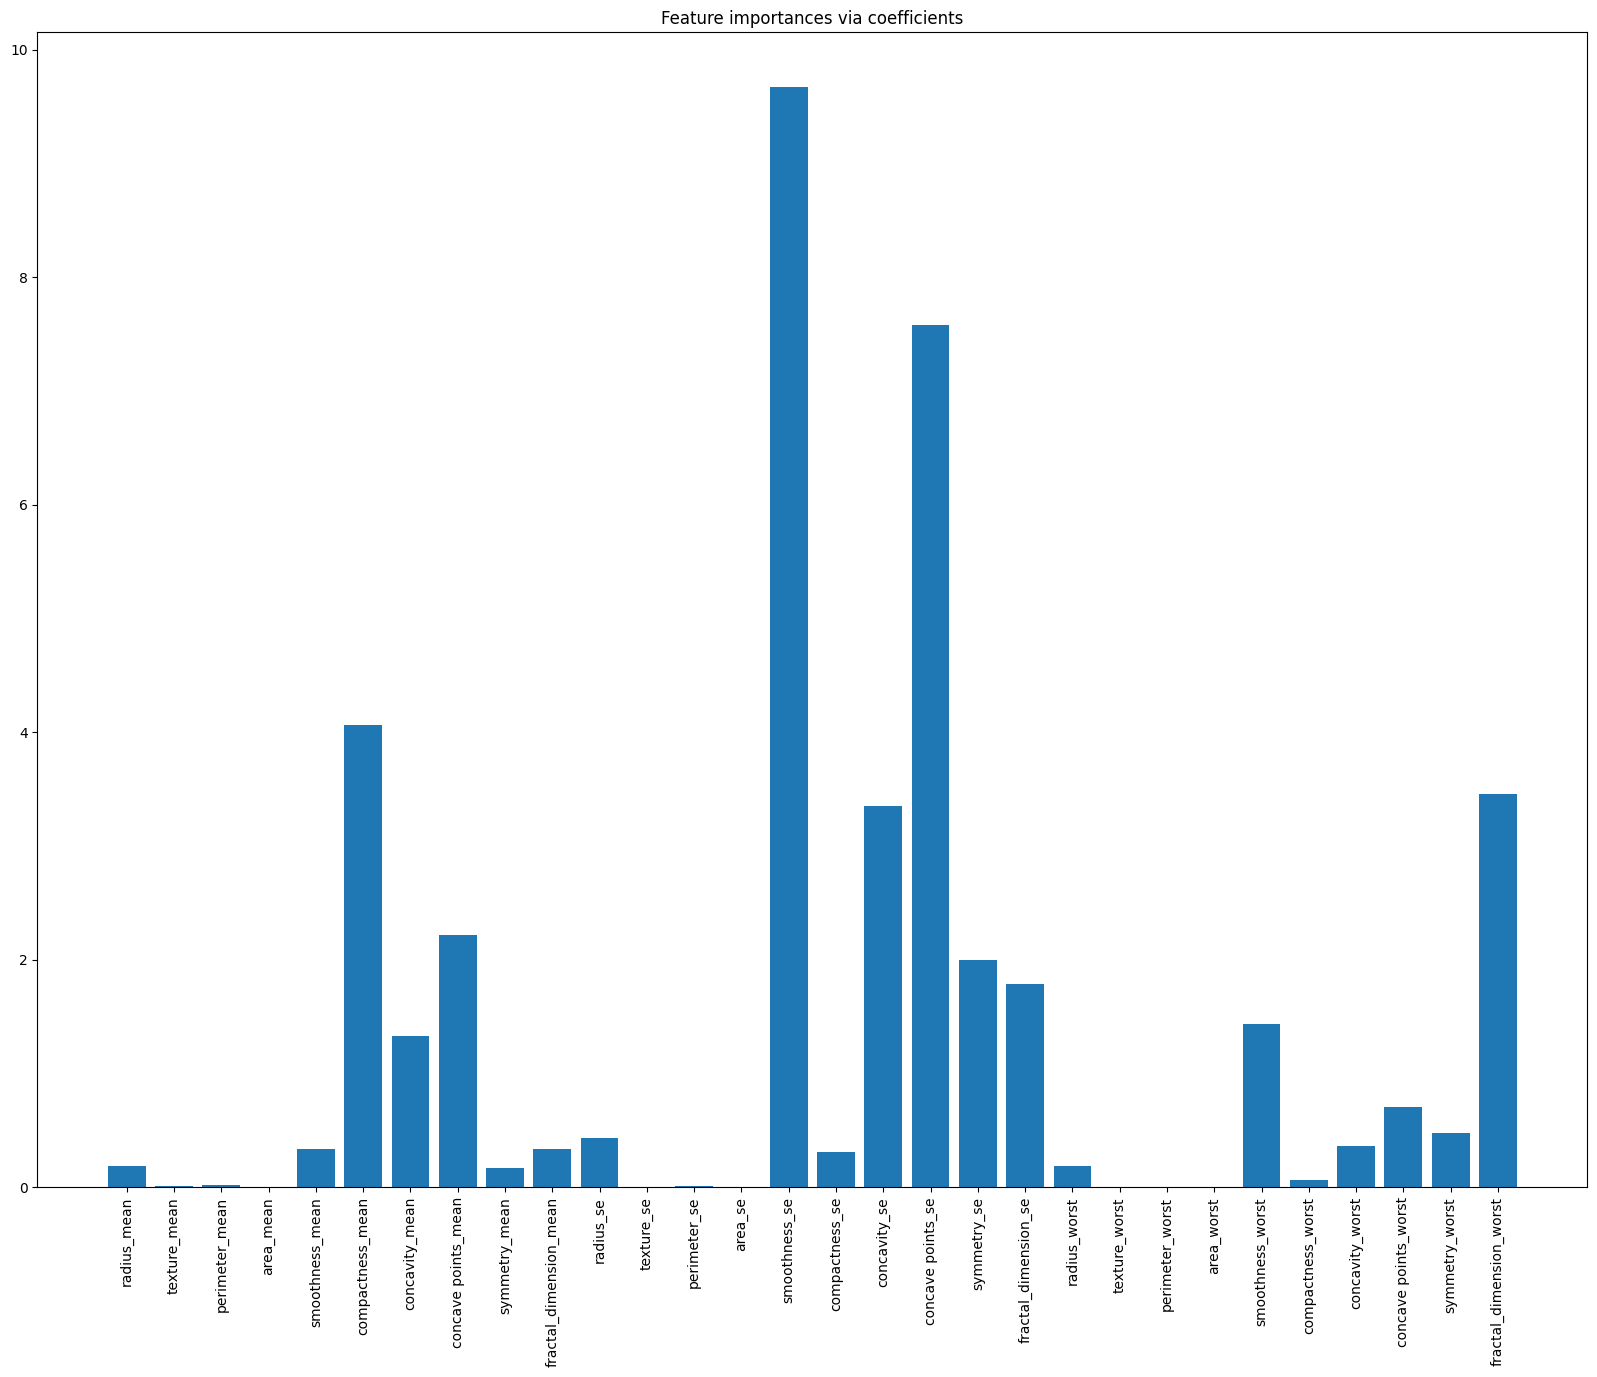

In [4]:
# Fit RidgeCV to get feature importances
ridge = RidgeCV(alphas=np.logspace(-6, 6, num=5)).fit(X, y)
importance = np.abs(ridge.coef_)
feature_names = np.array(X.columns)

plt.figure(figsize=(20, 15))
plt.bar(height=importance, x=feature_names)
plt.xticks(rotation=90)
plt.title("Feature importances via coefficients")
plt.show()

In [5]:
# Select features with importance above the 10th highest + small margin
threshold = np.sort(importance)[-11] + 0.01

tic = time()
sfm = SelectFromModel(ridge, threshold=threshold).fit(X, y)
toc = time()

print(f"Features selected by SelectFromModel: {X.columns[sfm.get_support()]}")
print(f"Done in {toc - tic:.3f}s")

Features selected by SelectFromModel: Index(['compactness_mean', 'concavity_mean', 'concave points_mean',
       'smoothness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'smoothness_worst', 'fractal_dimension_worst'],
      dtype='str')
Done in 0.004s


## Sequential feature selection

In [6]:
# Sequential feature selection
tic_fwd = time()
sfs_forward = SequentialFeatureSelector(
    ridge, n_features_to_select=10, direction="forward"
).fit(X, y)
toc_fwd = time()

tic_bwd = time()
sfs_backward = SequentialFeatureSelector(
    ridge, n_features_to_select=10, direction="backward"
).fit(X, y)
toc_bwd = time()

print(
    "Features selected by forward sequential selection: "
    f"{X.columns[sfs_forward.get_support()]}"
)
print(f"Done in {toc_fwd - tic_fwd:.3f}s")
print(
    "Features selected by backward sequential selection: "
    f"{X.columns[sfs_backward.get_support()]}"
)
print(f"Done in {toc_bwd - tic_bwd:.3f}s")

Features selected by forward sequential selection: Index(['radius_mean', 'area_mean', 'fractal_dimension_mean', 'smoothness_se',
       'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst',
       'concave points_worst', 'symmetry_worst'],
      dtype='str')
Done in 1.119s
Features selected by backward sequential selection: Index(['radius_mean', 'compactness_mean', 'concavity_mean', 'smoothness_se',
       'concavity_se', 'concave points_se', 'radius_worst', 'texture_worst',
       'area_worst', 'fractal_dimension_worst'],
      dtype='str')
Done in 2.574s


In [7]:
# Test different tolerance values for backward sequential selection

for tol in [-1e-2, -1e-3, -1e-4, -1e-5, -1e-6]:
    start = time()
    feature_selector = SequentialFeatureSelector(
        LogisticRegression(),
        n_features_to_select="auto",
        direction="backward",
        scoring="roc_auc",
        tol=tol,
        n_jobs=2,
    )

    model = make_pipeline(StandardScaler(), feature_selector, LogisticRegression())
    model.fit(X, y)
    end = time()

    print(f"\ntol: {tol}")
    print(f"Features selected: {feature_names[model[1].get_support()]}")
    print(f"ROC AUC score: {roc_auc_score(y, model.predict_proba(X)[:, 1]):.3f}")
    print(f"Done in {end - start:.3f}s")


tol: -0.01
Features selected: ['perimeter_worst']
ROC AUC score: 0.975
Done in 8.736s

tol: -0.001
Features selected: ['radius_se' 'fractal_dimension_se' 'texture_worst' 'perimeter_worst'
 'concave points_worst']
ROC AUC score: 0.997
Done in 6.174s

tol: -0.0001
Features selected: ['compactness_mean' 'concavity_mean' 'concave points_mean' 'radius_se'
 'area_se' 'concave points_se' 'symmetry_se' 'fractal_dimension_se'
 'texture_worst' 'perimeter_worst' 'area_worst' 'concave points_worst'
 'symmetry_worst']
ROC AUC score: 0.998
Done in 5.394s

tol: -1e-05
Features selected: ['area_mean' 'compactness_mean' 'concavity_mean' 'concave points_mean'
 'radius_se' 'texture_se' 'area_se' 'smoothness_se' 'concave points_se'
 'symmetry_se' 'fractal_dimension_se' 'texture_worst' 'perimeter_worst'
 'area_worst' 'compactness_worst' 'concave points_worst' 'symmetry_worst'
 'fractal_dimension_worst']
ROC AUC score: 0.998
Done in 4.252s

tol: -1e-06
Features selected: ['area_mean' 'compactness_mean' 'co

## L1 based feature selection

In [25]:
# Feature scaling — important for KNN, SVM, and Logistic Regression
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame for readability
X_scaled = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

In [ ]:
# Linear SVC [lasso] feature selection

lsvc = LinearSVC(C=0.1, penalty="l1", dual=False).fit(X_scaled, y)
model = SelectFromModel(lsvc, prefit=True)
X_new = model.transform(X_scaled)

X_new.shape
X_new = pd.DataFrame(X_new, columns=X.columns[model.get_support()])
X_new.columns

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


Index(['texture_mean', 'concave points_mean', 'fractal_dimension_mean',
       'radius_se', 'smoothness_se', 'compactness_se', 'fractal_dimension_se',
       'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst',
       'smoothness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst'],
      dtype='str')

## Feature importances with a forest of trees

In [56]:
# Train test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"\nTraining diagnosis rate: {y_train.mean():.2%}")
print(f"Test diagnosis rate: {y_test.mean():.2%}")

Training set: 455 samples
Test set: 114 samples

Training diagnosis rate: 37.36%
Test diagnosis rate: 36.84%


In [57]:
# fit random forest
feature_names = [X.columns]
forest = RandomForestClassifier(random_state=0)
forest.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

### Feature importance based on mean decrease in impurity (MDI) or (Gini importance)

They are computed as the mean and standard deviation of accumulation of the impurity decrease within each tree.

In [58]:
start_time = time()
importances = forest.feature_importances_
std = np.std([tree.feature_importances_ for tree in forest.estimators_], axis=0)
elapsed_time = time() - start_time

print(f"Elapsed time to compute the importances: {elapsed_time:.3f} seconds")

Elapsed time to compute the importances: 0.025 seconds


In [ ]:
n = 0
for tree in forest.estimators_:
    if n < 3:
        print(f"\nTree {tree}\nfeature importances: {tree.feature_importances_}")
        print(f"forest feature importances: {importances}")
        n += 1
    else:
        break

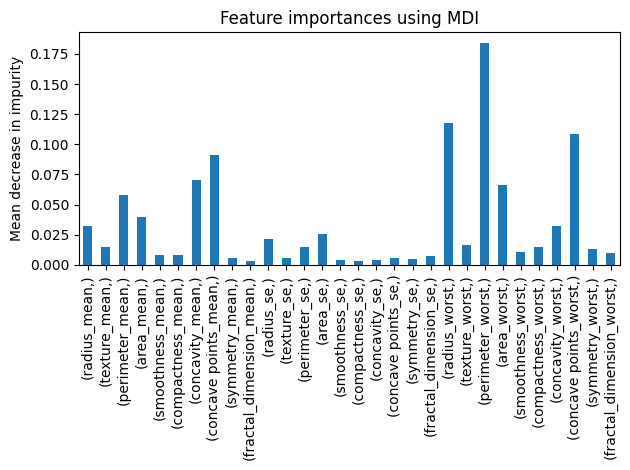

In [66]:
forest_importances = pd.Series(importances, index=feature_names)

fig, ax = plt.subplots()
forest_importances.plot.bar( ax=ax)
ax.set_title("Feature importances using MDI")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()

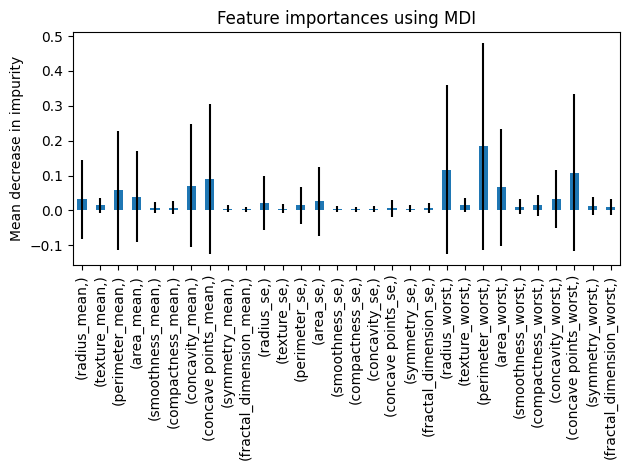

In [65]:
forest_importances = pd.Series(importances, index=feature_names)

fig, ax = plt.subplots()
forest_importances.plot.bar(yerr=std, ax=ax)
ax.set_title("Feature importances using MDI")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()

### Feature importance based on feature permutation

In [69]:
from sklearn.inspection import permutation_importance

start_time = time()
result = permutation_importance(
    forest, X_test, y_test, n_repeats=10, random_state=42, n_jobs=2
)
elapsed_time = time() - start_time
print(f"Elapsed time to compute the importances: {elapsed_time:.3f} seconds")

forest_importances = pd.Series(result.importances_mean, index=feature_names)

Elapsed time to compute the importances: 0.967 seconds


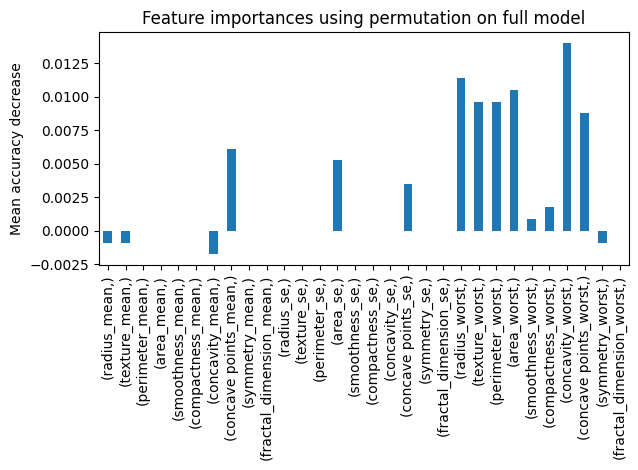

In [75]:
fig, ax = plt.subplots()
forest_importances.plot.bar(ax=ax)
ax.set_title("Feature importances using permutation on full model")
ax.set_ylabel("Mean accuracy decrease")
fig.tight_layout()
plt.show()

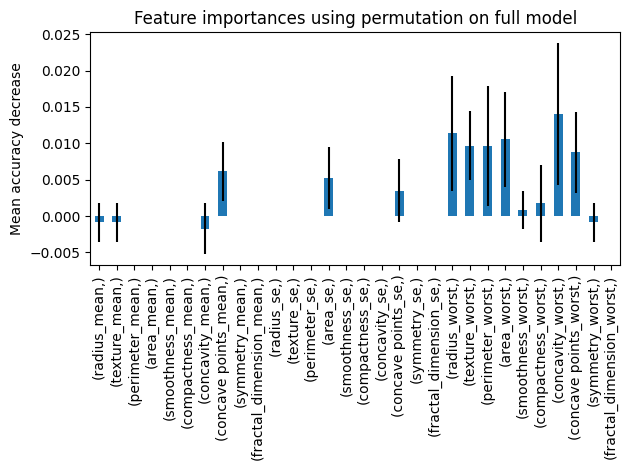

In [74]:
fig, ax = plt.subplots()
forest_importances.plot.bar(yerr=result.importances_std, ax=ax)
ax.set_title("Feature importances using permutation on full model")
ax.set_ylabel("Mean accuracy decrease")
fig.tight_layout()
plt.show()

In [73]:
print(result.importances_mean)
print(result.importances_std)

[-0.00087719 -0.00087719  0.          0.          0.          0.
 -0.00175439  0.00614035  0.          0.          0.          0.
  0.          0.00526316  0.          0.          0.          0.00350877
  0.          0.          0.01140351  0.00964912  0.00964912  0.01052632
  0.00087719  0.00175439  0.01403509  0.00877193 -0.00087719  0.        ]
[0.00263158 0.00263158 0.         0.         0.         0.
 0.00350877 0.0040198  0.         0.         0.         0.
 0.         0.00429735 0.         0.         0.         0.00429735
 0.         0.         0.00789474 0.00472383 0.00827542 0.00656431
 0.00263158 0.00526316 0.00976801 0.00554786 0.00263158 0.        ]


## 

In [10]:
# Univariate feature selection

# X_new = SelectKBest(f_classif, k=15).fit_transform(X, y)
# X_new.shape
X.columns[SelectKBest(f_classif, k=10).fit(X, y).get_support()]

Index(['radius_mean', 'perimeter_mean', 'area_mean', 'concavity_mean',
       'concave points_mean', 'radius_worst', 'perimeter_worst', 'area_worst',
       'concavity_worst', 'concave points_worst'],
      dtype='str')

Interestingly, forward and backward selection have not selected the same set of features. Forward selection selects area_mean, fractal_dimension_mean, texture_worst, perimeter_worst, concave points_worst, symmetry_worst

We also note that the features selected by SFS differ from those selected by feature importance: SFS selects bmi instead of s1. This does sound reasonable though, since bmi corresponds to the third most important feature according to the coefficients. It is quite remarkable considering that SFS makes no use of the coefficients at all.

To finish with, we should note that SelectFromModel is significantly faster than SFS. Indeed, SelectFromModel only needs to fit a model once, while SFS needs to cross-validate many different models for each of the iterations. SFS however works with any model, while SelectFromModel requires the underlying estimator to expose a coef_ attribute or a feature_importances_ attribute. The forward SFS is faster than the backward SFS because it only needs to perform n_features_to_select = 2 iterations, while the backward SFS needs to perform n_features - n_features_to_select = 8 iterations.